In [1]:
import sys
import os
import numpy as np
import importlib

# Remontée de deux niveaux pour accéder à Data_loader
current_dir = os.getcwd()
project_root = os.path.normpath(os.path.join(current_dir, "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Chemin du projet : {project_root}")

# Import du module de chargement des données
module_name = "RSA_deep_working.Data_loader.class_data_loaders"

try:
    class_data_loaders = importlib.import_module(module_name)
    DirectoryRSAClass = class_data_loaders.DirectoryRSAClass
except ModuleNotFoundError as e:
    print(f"Erreur lors de l'importation du module {module_name} : {e}")
    sys.exit(1)

Chemin du projet : /home/loai/Documents/code/RSMLExtraction


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import rsml
import tifffile


from RSA_deep_working.Data_loader.class_data_loaders import DirectoryRSAClass

# importing pretrained segmentation model
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/uc1_segmentation")
global_step = 0


2025-04-04 10:08:16.796954: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-04 10:08:16.806511: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743754096.818572   12495 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743754096.821926   12495 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743754096.830890   12495 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Dataset and data loaders

In [3]:
base_directory = "/home/loai/Images/DataTest/UC1_data"

In [4]:
from RSA_deep_working.Data_loader.class_data_loaders import DirectoryRSAClass
import os
import numpy as np
import tifffile
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

# Dimensions d'origine et calculs
H, W = (1166, 1348)

H_new, W_new = (1184, 1376)
padding_bottom, padding_right = H_new - H, W_new - W # the opposite lol
print("pad :", padding_right, padding_bottom)

# Transformations pré-calculées
img_transform = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Pad(padding=(0, 0, padding_right, padding_bottom), fill=0),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
mask_transform_series = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.Pad(padding=(0, 0, padding_right, padding_bottom), fill=0),
    
])
mask_transform_image = transforms.Compose([
    transforms.ToTensor(),
    
    #transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.Pad(padding=(0, 0, padding_right, padding_bottom), fill=0),
])

def mtg_transform(mtg):
    """
    Transforme le MTG en un tenseur PyTorch.
    """
    # Convertir le MTG en une représentation adaptée
    # Par exemple, convertir les coordonnées en tenseur
    # ou appliquer d'autres transformations spécifiques
    return mtg

pad : 28 18


In [5]:
# Optimisation de la lecture des TIFF : mise en cache par fichier
class CachedTiffReader:
    def __init__(self):
        self.cache = {}

    def get_page(self, img_path, key):
        if img_path not in self.cache:
            # Chargement unique du fichier, stockage de toutes les pages
            with tifffile.TiffFile(img_path) as tif:
                self.cache[img_path] = [page.asarray() for page in tif.pages]
        return self.cache[img_path][key]

tiff_reader = CachedTiffReader()

class RSASeg2DDataset(Dataset):
    def __init__(self, rsa_dir_loader, mode='series', img_transform=None,
                 mask_transform_series=None, mask_transform_image=None, image_with_mtg=False):
        """
        mode: 'series' pour charger l'ensemble de la série temporelle,
              'image' pour charger image par image.
        """
        self.mode = mode
        self.samples = []  # contiendra les tuples en fonction du mode
        self.img_transform = img_transform
        self.mask_transform_series = mask_transform_series
        self.mask_transform_image = mask_transform_image
        self.image_with_mtg = image_with_mtg

        for loader in rsa_dir_loader.loaders:
            img_path = loader.image_stack_path
            mask_path = loader.date_map_path
            mtg_path = loader.rsml_default_file if os.path.exists(
                loader.rsml_default_file) else loader.rsml_expert_file

            # Lecture du nombre de slices dans la série
            with tifffile.TiffFile(img_path) as tif:
                num_slices = len(tif.pages)

            if mode == 'series':
                # Une entrée par série temporelle complète
                self.samples.append(
                    (img_path, mask_path, num_slices, mtg_path))
            elif mode == 'image':
                # Une entrée par image (slice)
                for z in range(num_slices):
                    self.samples.append((img_path, mask_path, z, mtg_path))
            else:
                raise ValueError(
                    "Mode non reconnu, choisissez 'series' ou 'image'")

    def __len__(self):
        return len(self.samples)
    
    def num_times(self, idx):
        """
        Retourne le nombre de fois que l'image a été vue.
        """
        img_path, _, _, _ = self.samples[idx]
        with tifffile.TiffFile(img_path) as tif:
            num_slices = len(tif.pages)
        return num_slices

    def __getitem__(self, idx):
        
        if self.mode == 'series':
            # Chargement de la série complète
            img_path, mask_path, _, mtg_path = self.samples[idx]
            # Chargement complet de la série
            img = tifffile.imread(img_path)
            mask_loaded = tifffile.imread(mask_path)
            if self.img_transform:
                img = self.img_transform(img)
            if self.mask_transform_series:
                mask = self.mask_transform_series(mask_loaded)
        else:  # mode 'image'
            img_path, mask_path, z, mtg_path = self.samples[idx]
            img = tiff_reader.get_page(img_path, z)
            mask_loaded = tifffile.imread(mask_path)
            # if pixel value of mask is <= z, set it to 1 (but not 0)
            mask = np.zeros_like(mask_loaded)
            mask[mask_loaded <= z] = 1
            mask[mask_loaded == 0] = 0
            

            if self.img_transform:
                img = self.img_transform(img)
            if self.mask_transform_image:
                mask = self.mask_transform_image(mask)
        if self.image_with_mtg:
            return img, mask, z, mtg_path
        return img, mask, z, torch.tensor(0)

In [6]:

dir_loader = DirectoryRSAClass(base_directory, load_date_map=True, lazy=True)

# Pour entraîner image par image :
rsa_dataset_image = RSASeg2DDataset(
    dir_loader,
    mode='image',
    img_transform=img_transform,
    mask_transform_image=mask_transform_image,  # pipeline dédié
    image_with_mtg=True
)

print("Nombre d'échantillons :", len(rsa_dataset_image), "images\n")

# for reproducibility
torch.manual_seed(42)
np.random.seed(42)

generator = torch.Generator().manual_seed(42)

train_set, val_set, test_set = torch.utils.data.random_split(
    rsa_dataset_image,
    [int(len(rsa_dataset_image) * 0.7), int(len(rsa_dataset_image) * 0.2),
     int(len(rsa_dataset_image) * 0.1)+2],
    generator=generator
)

# Affichage des tailles des ensembles
print("Ensemble d'entraînement (image) :", len(train_set))
print("Ensemble de validation (image) :", len(val_set))
print("Ensemble de test (image) :", len(test_set))

Nombre d'échantillons : 754 images

Ensemble d'entraînement (image) : 527
Ensemble de validation (image) : 150
Ensemble de test (image) : 77


### 2D Image loaders

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

# data loader optimization
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=8, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)

Utilisation du device : cuda


Taille du batch : torch.Size([1, 1, 1184, 1376])
Taille du masque : torch.Size([1, 1, 1184, 1376])
Image : torch.Size([1, 1, 1184, 1376])
Masque : torch.Size([1, 1, 1184, 1376])


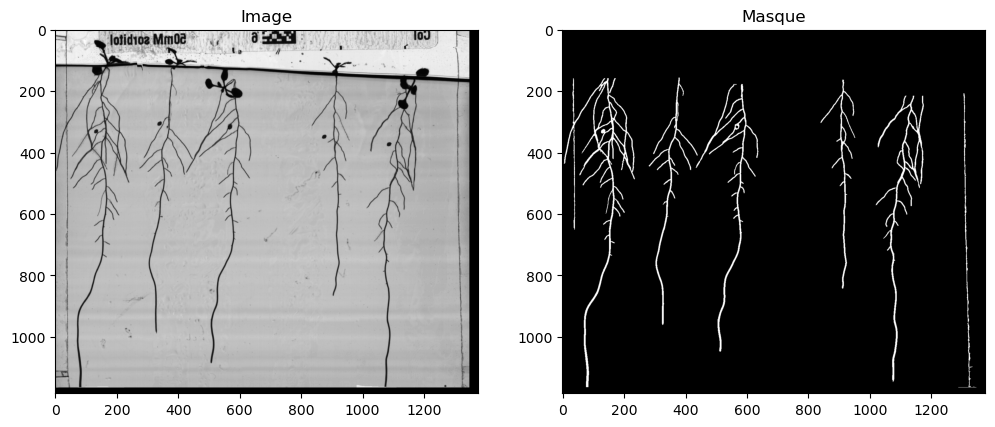

In [8]:
# plot example
batch = next(iter(train_loader))
print("Taille du batch :", batch[0].shape)
print("Taille du masque :", batch[1].shape)
img, mask, _, _ = batch
print("Image :", img.shape)
print("Masque :", mask.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img[0, 0].cpu(), cmap='gray')
ax[0].set_title("Image")
ax[1].imshow(mask[0, 0].cpu(), cmap='gray')
ax[1].set_title("Masque")   
plt.show()

## Evaluation

In [9]:
def evaluate_segmentation(model, image, mask, mtg, metrics:list, prediction=None, threshold=0.5, writer=None, global_step=None, device='cpu'):
    model.eval()
    image = image.to(device)
    mask = mask.to(device)

    # Calcul de la prédiction si non fournie
    if prediction is None:
        with torch.no_grad():
            output = model(image)
            # Supposons que le modèle renvoie des logits : on applique une sigmoïde
            pred = torch.sigmoid(output)
            # Binarisation (seuil à 0.5)
            prediction = (pred > threshold).float()
    
    # Calcul des métriques
    scores = {}
    for metric in metrics:
        scores[metric.__name__] = metric(prediction, mask, mtg)

    # Log des résultats dans TensorBoard si le SummaryWriter est fourni
    if writer is not None and global_step is not None:
        for metric_name, score in scores.items():
            writer.add_scalar(f"Eval/{metric_name}", score, global_step)

    # Retourne un dictionnaire de résultats
    return {
        'prediction': prediction,
        'scores': scores
    }

def evaluate_segmentation_on_loader(model, loader, metrics:list, threshold=0.5, writer=None, global_step=None, device='cpu'):
    """
    Évalue le modèle sur un DataLoader donné.
    """
    model.eval()
    all_scores = []
    all_predictions = []
    all_masks = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluation iteration", position=1, leave=False, dynamic_ncols=True):
            images, masks, time, mtgs = batch
            images = images.to(device)
            masks = masks.to(device)

            
            # Calcul de la prédiction si non fournie
            output = model(images)
            pred = torch.sigmoid(output)
            prediction = (pred > threshold).float()
            
            # Calcul des métriques
            scores = {}
            for metric in metrics:
                scores[metric.__name__] = metric(prediction.squeeze(1), masks.squeeze(1), time, mtgs[0])

            all_scores.append(scores)
            all_predictions.append(prediction.cpu())
            all_masks.append(masks.cpu())

        # Log des résultats dans TensorBoard si le SummaryWriter est fourni
        if writer is not None and global_step is not None:
            for metric_name in metrics:
                avg_score = np.mean([score[metric_name.__name__] for score in all_scores])
                writer.add_scalar(f"Eval/{metric_name.__name__}", avg_score, global_step)
            # pour une certaine seed, on peut loguer quelques images
            writer.add_images("Eval/Images", images[:5], global_step)
            writer.add_images("Eval/output", output[:5], global_step)
            writer.add_images("Eval/map_prediction", pred[:5], global_step)
            writer.add_images("Eval/Predictions", prediction[:5], global_step)
            writer.add_images("Eval/Masks", masks[:5], global_step)
            writer
            writer.flush()
            global_step += 1

    return {
        'scores': all_scores,
        'predictions': torch.cat(all_predictions),
        'masks': torch.cat(all_masks)
    }


In [10]:
import RSA_deep_working.Metrics.simple_metrics as sm
import RSA_deep_working.Metrics.topo_explicit_metrics as tm

metrics = sm.all_metrics() 
tubular_metrics = tm.all_metrics()
print("Métriques disponibles :")
for metric in metrics:
    print(f"- {metric.__name__}")
    
print("Métriques tubulaires disponibles :")
for metric in tubular_metrics:
    print(f"- {metric.__name__}")
    
all_metrics = []
for metric in metrics:
    all_metrics.append(metric)
for metric in tubular_metrics:
    all_metrics.append(metric)

Métriques disponibles :
- dice
- f1_score
- iou
- pixel_accuracy
- precision
- recall
- specificity
- connectivity_metric
- ARI_index
- VI_index
- ARE_error
- betti_0_difference
- betti_1_difference
- euler_charac_difference
Métriques tubulaires disponibles :
- cldice
- skeleton_recall
- Connectivity_Preserving_Instance_Segmentation
- evaluate_sk_seg


## Model

In [11]:
model_pretrained = smp.Unet(
    encoder_name="resnet34",       
    encoder_weights="imagenet",    
    in_channels=1,                 
    classes=1                      
)

# loading pretrained weights
#model_pretrained.load_state_dict(torch.load("/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/Existing_models/model_BCE_100epoch.pth"))

In [ ]:
# test des deux modèles selon chaques metriques 
model_pretrained.to(device)

# Evaluation sur l'ensemble de validation
print("Evaluation du modèle pré-entraîné sur l'ensemble de validation")
results_pretrained = evaluate_segmentation_on_loader(
    model_pretrained,
    val_loader,
    metrics=all_metrics,
    threshold=0.5,
    writer=writer,
    global_step=global_step,
    device=device
)
print("Résultats du modèle pré-entraîné :")
for metric_name, score in results_pretrained['scores'][0].items():
    print(f"{metric_name}: {score:.4f}")

Evaluation du modèle pré-entraîné sur l'ensemble de validation


Evaluation iteration:   0%|          | 0/150 [00:00<?, ?it/s]

/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/Metrics/simple_metrics.py:133: RuntimeWarning: invalid value encountered in scalar divide
  scores.append(abs(betti1_pred - betti1_mask) / (betti1_pred + betti1_mask))  # normalized
/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/Metrics/simple_metrics.py:133: RuntimeWarning: invalid value encountered in scalar divide
  scores.append(abs(betti1_pred - betti1_mask) / (betti1_pred + betti1_mask))  # normalized
/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/Metrics/simple_metrics.py:144: RuntimeWarning: divide by zero encountered in scalar divide
  scores.append(abs(euler_pred - euler_mask) / (euler_pred + euler_mask)) # normalized


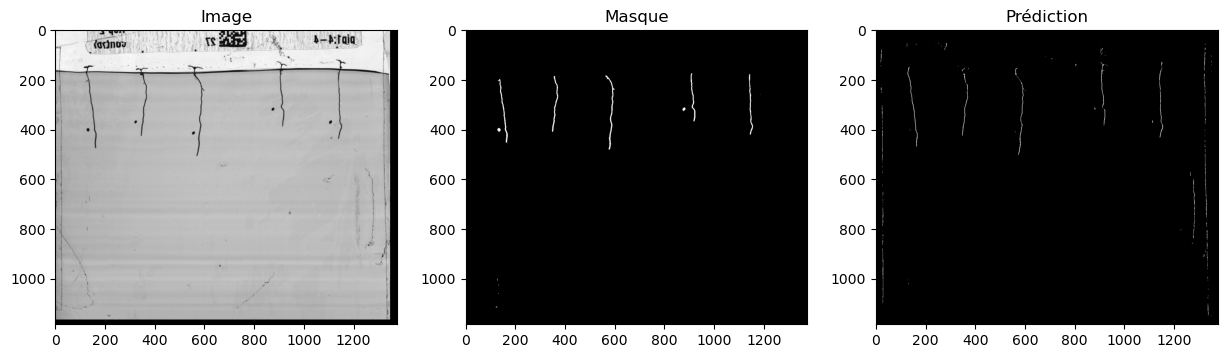

In [ ]:
#plot an prediction 
def plot_prediction(image, mask, prediction):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(image.squeeze(0).cpu(), cmap='gray')
    ax[0].set_title("Image")
    ax[1].imshow(mask.squeeze(0).cpu(), cmap='gray')
    ax[1].set_title("Masque")
    ax[2].imshow(prediction.squeeze(0).cpu(), cmap='gray')
    ax[2].set_title("Prédiction")
    plt.show()
    
# plot a random image from the validation set
import random
idx = random.randint(0, len(val_set)-1)
image, mask, time, mtg = val_set[idx]
plot_prediction(image, mask, results_pretrained['predictions'][idx])

In [ ]:
import cProfile
import pstats

# profiling de chaques metrique dans all_metrics
def profile_metrics(metrics, loader):
    for metric in metrics:
        profiler = cProfile.Profile()
        for batch in loader:
            images, masks, time, mtgs = batch
            images = images.to(device)
            masks = masks.to(device)
            profiler.enable()
            metric(images.squeeze(1), masks.squeeze(1), time, mtgs)
            profiler.disable()
        stats = pstats.Stats(profiler)
        stats.sort_stats('cumulative')
        stats.print_stats()
# Profiling des métriques
image, mask, time, mtg = val_set[0]
profile_metrics(all_metrics, val_loader)


         4650 function calls in 0.115 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      150    0.003    0.000    0.112    0.001 /home/loai/Documents/code/RSMLExtraction/RSA_deep_working/Metrics/simple_metrics.py:21(dice)
      150    0.002    0.000    0.096    0.001 /home/loai/miniforge3/envs/openalea/lib/python3.10/site-packages/torchmetrics/functional/segmentation/dice.py:103(dice_score)
      150    0.032    0.000    0.068    0.000 /home/loai/miniforge3/envs/openalea/lib/python3.10/site-packages/torchmetrics/functional/segmentation/dice.py:79(_dice_score_compute)
      150    0.010    0.000    0.026    0.000 /home/loai/miniforge3/envs/openalea/lib/python3.10/site-packages/torchmetrics/utilities/compute.py:49(_safe_divide)
      150    0.011    0.000    0.026    0.000 /home/loai/miniforge3/envs/openalea/lib/python3.10/site-packages/torchmetrics/functional/segmentation/dice.py:48(_dice_score_update)
      750    0.01

RuntimeError: Detected the following values in `preds`: tensor([-1,  0], device='cuda:0', dtype=torch.int32) but expected only the following values [0,1] since `preds` is a label tensor.

## Training

In [ ]:
# Train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cpu', writer=None):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", position=0, leave=True, dynamic_ncols=True):
            images, masks, _ = batch
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        #print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

        # Log the loss to TensorBoard
        if writer is not None:
            writer.add_scalar("Loss/train", epoch_loss, epoch)

        # Evaluation on validation set
        if val_loader is not None:
            evaluate_segmentation_on_loader(
                model,
                val_loader,
                metrics=all_metrics,
                threshold=0.5,
                writer=writer,
                global_step=epoch,
                device=device
            )

    return model

In [ ]:
# cuda - clear cache
torch.cuda.empty_cache()

In [ ]:
# Define the model, loss function, and optimizer - DICE
loss_fn = smp.losses.DiceLoss(
    mode='binary')
optimizer = optim.Adam(model_pretrained.parameters(), lr=5e-5)

# Train the model
model_trained = train_model(
    model_pretrained,
    train_loader,
    val_loader,
    criterion=loss_fn,
    optimizer=optimizer,
    num_epochs=100,
    device=device,
    writer=writer
)

Epoch 1/100:   0%|          | 0/17 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/17 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/17 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/17 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 5/100:   0%|          | 0/17 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# save the model
torch.save(model_trained.state_dict(), "model_DICE_100epoch.pth")